<a href="https://colab.research.google.com/github/khadija2027/Medical-image-classification-using-QCNN/blob/main/CNN%20VS%20QCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL AND IMPORT**

In [1]:
!pip install medmnist -q
!pip install pennylane -q

import os, pickle, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, models
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             average_precision_score, roc_curve,
                             precision_recall_curve)
from scipy.stats import binomtest
from medmnist import PneumoniaMNIST
from google.colab import drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 52.6 MB/s eta 0:00:00


**Data pre-processing**

In [13]:
drive.mount('/content/drive', force_remount=True)

DRIVE_PATH = '/content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/QCNN_VS_CNN(3)'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CKPT_DIR = os.path.join(DRIVE_PATH, 'sweep_checkpoints')
PLOT_DIR = os.path.join(DRIVE_PATH, 'sweep_plots')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

Mounted at /content/drive
Using device: cpu


In [9]:
TRAIN_SIZES = [None]         # None = full set.
BATCH_SIZE  = 32
EPOCHS      = 30             # room for slow quantum optimisation
PATIENCE    = 8              # on the SELECTION metric (val AUC), not raw loss
MIN_EPOCHS  = 10             # never early-stop before this
LR_CLASS    = 1e-3           # classical models (CNN and CNN_Big)
LR_QCNN     = 0.01           # quantum model
SIZE_SEEDS  = [42, 13, 100]
N_QUBITS = 8

COLORS  = {'CNN': '#1f77b4', 'QCNN': '#d62728', 'CNN_Big': '#2ca02c'}
MARKERS = {'CNN': 'o',       'QCNN': 'D',       'CNN_Big': 's'}

# DATA TRANSFORMS
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# LOAD DATASET
train_dataset = PneumoniaMNIST(split="train", download=True, size=28, transform=train_transform)
val_dataset   = PneumoniaMNIST(split="val",   download=True, size=28, transform=val_transform)
test_dataset  = PneumoniaMNIST(split="test",  download=True, size=28, transform=val_transform)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# CREATE DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 4708, Val: 524, Test: 624


In [4]:
def prep_hybrid(img):
    """28x28 -> 20 features: 16 for amplitude (q0-q3) + 4 for angle (q4-q7)."""
    b = img.size(0)
    amp = F.adaptive_avg_pool2d(img, (4, 4)).reshape(b, -1)       # (B,16)
    ang = F.adaptive_avg_pool2d(img, (2, 2)).reshape(b, -1)       # (B,4)
    ang = (ang + 1.0) / 2.0 * np.pi
    return torch.cat([amp, ang], dim=1)                           # (B,20)


class CNN(nn.Module):
    """56-param classical control — same 20 pooled features as the QCNN.

    A genuine 1D convolution over the flattened feature vector (analogous to the
    parameter-matched CNN used as a scientific control against a QCNN). Outputs a
    LOGIT (classical path -> BCEWithLogitsLoss).

        Conv1d(1 -> 5, kernel=9)  ->  5*9 + 5 = 50
        Linear(5 -> 1)            ->  5   + 1 =  6   ==> 56 total
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(1, 5, kernel_size=9)   # (B,1,20) -> (B,5,12)
        self.pool = nn.AdaptiveAvgPool1d(1)          # -> (B,5,1)
        self.fc   = nn.Linear(5, 1)

    def forward(self, img):
        x = prep_hybrid(img).unsqueeze(1)            # (B,1,20)
        x = torch.tanh(self.conv(x))                 # (B,5,12)
        x = self.pool(x).squeeze(-1)                 # (B,5)
        return self.fc(x).view(-1)                   # logit


class CNN_Big(nn.Module):
    """Larger, unconstrained classical CNN — same 20 pooled features as the QCNN,
    but WITHOUT the 56-parameter budget constraint. This is a classical
    "how good can a normal-sized network get on this same data" benchmark,
    complementing the strict, param-matched CNN control.

        Conv1d(1 -> 16, kernel=5, pad=2)   -> 1*16*5 + 16   =   96
        Conv1d(16 -> 32, kernel=3, pad=1)  -> 16*32*3 + 32  = 1568
        Linear(32 -> 32)                   -> 32*32 + 32    = 1056
        Linear(32 -> 1)                    -> 32 + 1        =   33
                                                    total    = 2753
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)   # (B,1,20) -> (B,16,20)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)  # -> (B,32,20)
        self.pool  = nn.AdaptiveAvgPool1d(1)                      # -> (B,32,1)
        self.fc1   = nn.Linear(32, 32)
        self.fc2   = nn.Linear(32, 1)

    def forward(self, img):
        x = prep_hybrid(img).unsqueeze(1)             # (B,1,20)
        x = torch.relu(self.conv1(x))                 # (B,16,20)
        x = torch.relu(self.conv2(x))                 # (B,32,20)
        x = self.pool(x).squeeze(-1)                   # (B,32)
        x = torch.relu(self.fc1(x))                    # (B,32)
        return self.fc2(x).view(-1)                    # logit


def hybrid_encode(inputs):
    qml.AmplitudeEmbedding(inputs[..., :16], wires=range(4),
                           normalize=True, pad_with=0.0)
    qml.AngleEmbedding(inputs[..., 16:20], wires=range(4, 8), rotation="Y")


def conv_block(w, wires):
    a, b = wires
    qml.RY(w[0], wires=a); qml.RY(w[1], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(w[2], wires=a); qml.RY(w[3], wires=b)
    qml.CNOT(wires=[b, a])
    qml.RY(w[4], wires=a); qml.RY(w[5], wires=b)


def pool_block(w, wires):
    a, b = wires
    qml.CRZ(w[0], wires=[a, b])
    qml.PauliX(wires=a)
    qml.CRX(w[1], wires=[a, b])


def qcnn_circuit(inputs, conv1, pool1, conv2, pool2, conv3, pool3):
    hybrid_encode(inputs)
    for i, pr in enumerate([(0, 1), (2, 3), (4, 5), (6, 7)]):
        conv_block(conv1[i], pr); pool_block(pool1[i], pr)
    for i, pr in enumerate([(1, 3), (5, 7)]):
        conv_block(conv2[i], pr); pool_block(pool2[i], pr)
    conv_block(conv3[0], (3, 7)); pool_block(pool3[0], (3, 7))
    return qml.expval(qml.PauliZ(7))


WEIGHT_SHAPES = {
    "conv1": (4, 6), "pool1": (4, 2),
    "conv2": (2, 6), "pool2": (2, 2),
    "conv3": (1, 6), "pool3": (1, 2),
}   # 24+8+12+4+6+2 = 56 trainable quantum parameters


class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()
        dev = qml.device("default.qubit", wires=N_QUBITS)
        qnode = qml.QNode(qcnn_circuit, dev, interface="torch", diff_method="backprop")
        self.qlayer = qml.qnn.TorchLayer(qnode, WEIGHT_SHAPES)

    def forward(self, img):
        feats = prep_hybrid(img)
        z = self.qlayer(feats).reshape(-1)     # expval(Z) in [-1, 1]
        p = (1.0 - z) / 2.0                    # prob of class 1
        return p.clamp(1e-6, 1 - 1e-6)


MODELS = {
    "CNN":     CNN,
    "QCNN":    HybridQCNN,
    "CNN_Big": CNN_Big}

In [6]:
def _is_prob_model(name):
    """Models whose forward() already returns a probability in [0,1] (not a logit)."""
    return name == 'QCNN'


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def set_seed(s):
    import random; random.seed(s)
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def dataset_labels(ds):
    lab = getattr(ds, 'labels', None)
    if lab is not None:
        return np.asarray(lab).reshape(-1).astype(int)
    return np.array([int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))])


def nested_subsets(labels, sizes, seed):
    rng = np.random.RandomState(seed)
    order = {c: rng.permutation(np.where(labels == c)[0]) for c in np.unique(labels)}
    out = {}
    for n in sizes:
        if n is None or n >= len(labels):
            out[n] = np.arange(len(labels)); continue
        idx = []
        for c, pool in order.items():
            k = int(round(n * len(pool) / len(labels)))
            idx.append(pool[:k])
        out[n] = np.sort(np.concatenate(idx))
    return out


def subset_loader(full_ds, labels, size, seed):
    if size is None:
        ds = full_ds
    else:
        idx = nested_subsets(labels, [size], seed)[size]
        ds = Subset(full_ds, idx.tolist())
    # No BatchNorm in any model -> keep every sample (important at small n).
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


# ── checkpointing ───────────────────────────────────────────────────────
def _model_path(name, sz, seed):
    return os.path.join(CKPT_DIR, f"{name}_sz{sz}_s{seed}.pth")

def _result_path(name, sz, seed):
    return os.path.join(CKPT_DIR, f"{name}_sz{sz}_s{seed}_result.pkl")

def is_done(name, sz, seed):
    return os.path.exists(_result_path(name, sz, seed))

def save_run(name, sz, seed, model, result):
    torch.save(model.state_dict(), _model_path(name, sz, seed))
    with open(_result_path(name, sz, seed), 'wb') as f:
        pickle.dump(result, f)

def load_result(name, sz, seed):
    with open(_result_path(name, sz, seed), 'rb') as f:
        return pickle.load(f)


# %% ── TRAIN / EVAL — identical selection rule (val ROC-AUC) for all models
def fit(model, name, tl, vl, dev):
    model = model.to(dev)
    is_prob = _is_prob_model(name)
    crit = nn.BCELoss() if is_prob else nn.BCEWithLogitsLoss()
    lr   = LR_QCNN     if is_prob else LR_CLASS
    opt  = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=4, factor=0.5)

    best, best_state, bad = -1.0, None, 0
    train_losses, val_losses, train_accs, val_accs, val_aucs = [], [], [], [], []

    for ep in range(EPOCHS):
        # ---- train ----
        model.train(); ep_loss, correct, total = 0.0, 0, 0
        for data, targets in tl:
            data = data.to(dev); targets = targets.to(dev).float().view(-1)
            out = model(data).view(-1)
            loss = crit(out, targets)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * targets.size(0)
            probs = out if is_prob else torch.sigmoid(out)
            correct += ((probs > 0.5).float() == targets).sum().item()
            total   += targets.size(0)
        train_losses.append(ep_loss / total)
        train_accs.append(correct / total)

        # ---- val (one pass -> loss, acc, AND auc) ----
        model.eval(); vl_loss, vc, vt = 0.0, 0, 0
        vp_all, vy_all = [], []
        with torch.no_grad():
            for data, targets in vl:
                data = data.to(dev); targets = targets.to(dev).float().view(-1)
                out = model(data).view(-1)
                vl_loss += crit(out, targets).item() * targets.size(0)
                probs = out if is_prob else torch.sigmoid(out)
                vc += ((probs > 0.5).float() == targets).sum().item()
                vt += targets.size(0)
                vp_all.extend(probs.detach().cpu().numpy())
                vy_all.extend(targets.detach().cpu().numpy())
        val_losses.append(vl_loss / vt); val_accs.append(vc / vt)

        try:
            score = roc_auc_score(vy_all, vp_all)      # threshold-free selection metric
        except ValueError:
            score = 0.0                                # single-class val guard
        val_aucs.append(score)

        sched.step(score)
        if score > best + 1e-4:
            best = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if ep + 1 >= MIN_EPOCHS and bad >= PATIENCE:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses, train_accs, val_accs, val_aucs


@torch.no_grad()
def get_probs(model, name, loader, dev):
    model.eval(); is_prob = _is_prob_model(name)
    P, Y = [], []
    for data, targets in loader:
        data = data.to(dev)
        out = model(data).view(-1)
        probs = out if is_prob else torch.sigmoid(out)
        P.extend(probs.cpu().numpy())
        Y.extend(targets.float().view(-1).cpu().numpy())
    return np.array(P), np.array(Y)


def tune_threshold(p, y):
    ts = np.linspace(0.05, 0.95, 91)
    return float(ts[int(np.argmax([f1_score(y, p > t, zero_division=0) for t in ts]))])


def metrics_at(p, y, thr):
    pred = (p > thr).astype(float)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return {'threshold': thr, 'accuracy': accuracy_score(y, pred),
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'specificity': spec, 'f1': f1_score(y, pred, zero_division=0)}


def evaluate(model, name, vl, tl, dev):
    vp, vy = get_probs(model, name, vl, dev)
    tp_, ty = get_probs(model, name, tl, dev)
    thr = tune_threshold(vp, vy)      # threshold tuned on VAL, applied to TEST
    return {
        'auc':         roc_auc_score(ty, tp_),
        'pr_auc':      average_precision_score(ty, tp_),
        'tuned':       metrics_at(tp_, ty, thr),
        'half':        metrics_at(tp_, ty, 0.5),
        'test_probs':  tp_,
        'test_labels': ty,
    }

In [7]:
def _is_prob_model(name):
    """Models whose forward() already returns a probability in [0,1] (not a logit)."""
    return name == 'QCNN'


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def set_seed(s):
    import random; random.seed(s)
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def dataset_labels(ds):
    lab = getattr(ds, 'labels', None)
    if lab is not None:
        return np.asarray(lab).reshape(-1).astype(int)
    return np.array([int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))])


def nested_subsets(labels, sizes, seed):
    rng = np.random.RandomState(seed)
    order = {c: rng.permutation(np.where(labels == c)[0]) for c in np.unique(labels)}
    out = {}
    for n in sizes:
        if n is None or n >= len(labels):
            out[n] = np.arange(len(labels)); continue
        idx = []
        for c, pool in order.items():
            k = int(round(n * len(pool) / len(labels)))
            idx.append(pool[:k])
        out[n] = np.sort(np.concatenate(idx))
    return out


def subset_loader(full_ds, labels, size, seed):
    if size is None:
        ds = full_ds
    else:
        idx = nested_subsets(labels, [size], seed)[size]
        ds = Subset(full_ds, idx.tolist())
    # No BatchNorm in any model -> keep every sample (important at small n).
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


# ── checkpointing ───────────────────────────────────────────────────────
def _model_path(name, sz, seed):
    return os.path.join(CKPT_DIR, f"{name}_sz{sz}_s{seed}.pth")

def _result_path(name, sz, seed):
    return os.path.join(CKPT_DIR, f"{name}_sz{sz}_s{seed}_result.pkl")

def is_done(name, sz, seed):
    return os.path.exists(_result_path(name, sz, seed))

def save_run(name, sz, seed, model, result):
    torch.save(model.state_dict(), _model_path(name, sz, seed))
    with open(_result_path(name, sz, seed), 'wb') as f:
        pickle.dump(result, f)

def load_result(name, sz, seed):
    with open(_result_path(name, sz, seed), 'rb') as f:
        return pickle.load(f)


# %% ── TRAIN / EVAL — identical selection rule (val ROC-AUC) for all models
def fit(model, name, tl, vl, dev):
    model = model.to(dev)
    is_prob = _is_prob_model(name)
    crit = nn.BCELoss() if is_prob else nn.BCEWithLogitsLoss()
    lr   = LR_QCNN     if is_prob else LR_CLASS
    opt  = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=4, factor=0.5)

    best, best_state, bad = -1.0, None, 0
    train_losses, val_losses, train_accs, val_accs, val_aucs = [], [], [], [], []

    for ep in range(EPOCHS):
        # ---- train ----
        model.train(); ep_loss, correct, total = 0.0, 0, 0
        for data, targets in tl:
            data = data.to(dev); targets = targets.to(dev).float().view(-1)
            out = model(data).view(-1)
            loss = crit(out, targets)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * targets.size(0)
            probs = out if is_prob else torch.sigmoid(out)
            correct += ((probs > 0.5).float() == targets).sum().item()
            total   += targets.size(0)
        train_losses.append(ep_loss / total)
        train_accs.append(correct / total)

        # ---- val (one pass -> loss, acc, AND auc) ----
        model.eval(); vl_loss, vc, vt = 0.0, 0, 0
        vp_all, vy_all = [], []
        with torch.no_grad():
            for data, targets in vl:
                data = data.to(dev); targets = targets.to(dev).float().view(-1)
                out = model(data).view(-1)
                vl_loss += crit(out, targets).item() * targets.size(0)
                probs = out if is_prob else torch.sigmoid(out)
                vc += ((probs > 0.5).float() == targets).sum().item()
                vt += targets.size(0)
                vp_all.extend(probs.detach().cpu().numpy())
                vy_all.extend(targets.detach().cpu().numpy())
        val_losses.append(vl_loss / vt); val_accs.append(vc / vt)

        try:
            score = roc_auc_score(vy_all, vp_all)      # threshold-free selection metric
        except ValueError:
            score = 0.0                                # single-class val guard
        val_aucs.append(score)

        sched.step(score)
        if score > best + 1e-4:
            best = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if ep + 1 >= MIN_EPOCHS and bad >= PATIENCE:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses, train_accs, val_accs, val_aucs


@torch.no_grad()
def get_probs(model, name, loader, dev):
    model.eval(); is_prob = _is_prob_model(name)
    P, Y = [], []
    for data, targets in loader:
        data = data.to(dev)
        out = model(data).view(-1)
        probs = out if is_prob else torch.sigmoid(out)
        P.extend(probs.cpu().numpy())
        Y.extend(targets.float().view(-1).cpu().numpy())
    return np.array(P), np.array(Y)


def tune_threshold(p, y):
    ts = np.linspace(0.05, 0.95, 91)
    return float(ts[int(np.argmax([f1_score(y, p > t, zero_division=0) for t in ts]))])


def metrics_at(p, y, thr):
    pred = (p > thr).astype(float)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return {'threshold': thr, 'accuracy': accuracy_score(y, pred),
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'specificity': spec, 'f1': f1_score(y, pred, zero_division=0)}


def evaluate(model, name, vl, tl, dev):
    vp, vy = get_probs(model, name, vl, dev)
    tp_, ty = get_probs(model, name, tl, dev)
    thr = tune_threshold(vp, vy)      # threshold tuned on VAL, applied to TEST
    return {
        'auc':         roc_auc_score(ty, tp_),
        'pr_auc':      average_precision_score(ty, tp_),
        'tuned':       metrics_at(tp_, ty, thr),
        'half':        metrics_at(tp_, ty, 0.5),
        'test_probs':  tp_,
        'test_labels': ty,
    }



Models: ['CNN', 'QCNN', 'CNN_Big']
Seeds : [42, 13, 100]
All models see the SAME 20 pooled features; selection metric = val ROC-AUC.
Trainable parameters:
  CNN     : 56
  QCNN    : 56
  CNN_Big : 2753
Full train set: 4708 samples, pneumonia frac 0.742

TRAIN SIZE = 4708
  CNN      seed=42   training on 4708 samples … AUC=0.7139  (136.0s)
  CNN      seed=13   training on 4708 samples … AUC=0.7206  (136.2s)
  CNN      seed=100  training on 4708 samples … AUC=0.7490  (135.4s)
  QCNN     seed=42   training on 4708 samples … AUC=0.8682  (177.6s)
  QCNN     seed=13   training on 4708 samples … AUC=0.8629  (199.7s)
  QCNN     seed=100  training on 4708 samples … AUC=0.8427  (181.7s)
  CNN_Big  seed=42   training on 4708 samples … AUC=0.9146  (149.6s)
  CNN_Big  seed=13   training on 4708 samples … AUC=0.9121  (146.2s)
  CNN_Big  seed=100  training on 4708 samples … AUC=0.9158  (148.0s)

Saved aggregate -> /content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/QCNN_VS_C

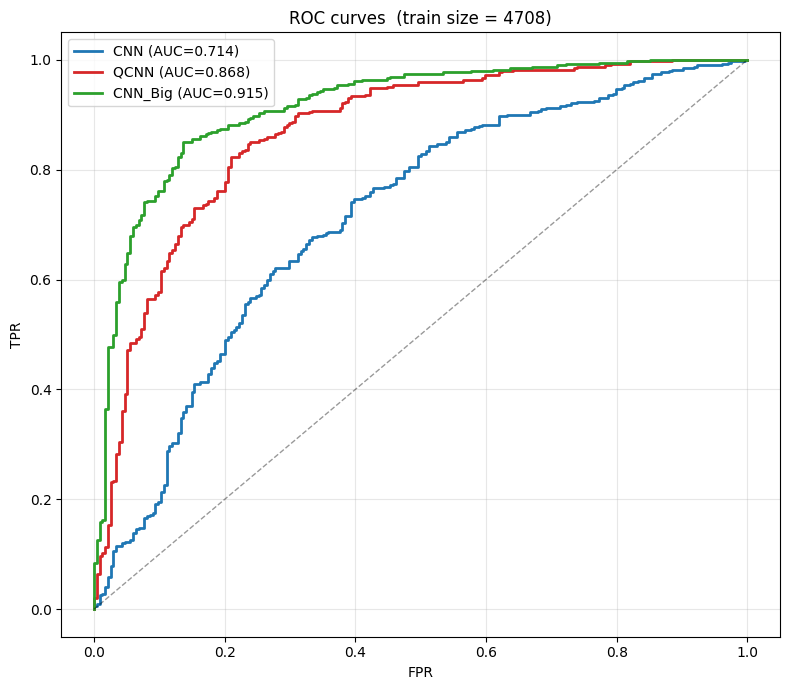

  Saved /content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/QCNN_VS_CNN(3)/sweep_plots/pr_curve_sz4708.png


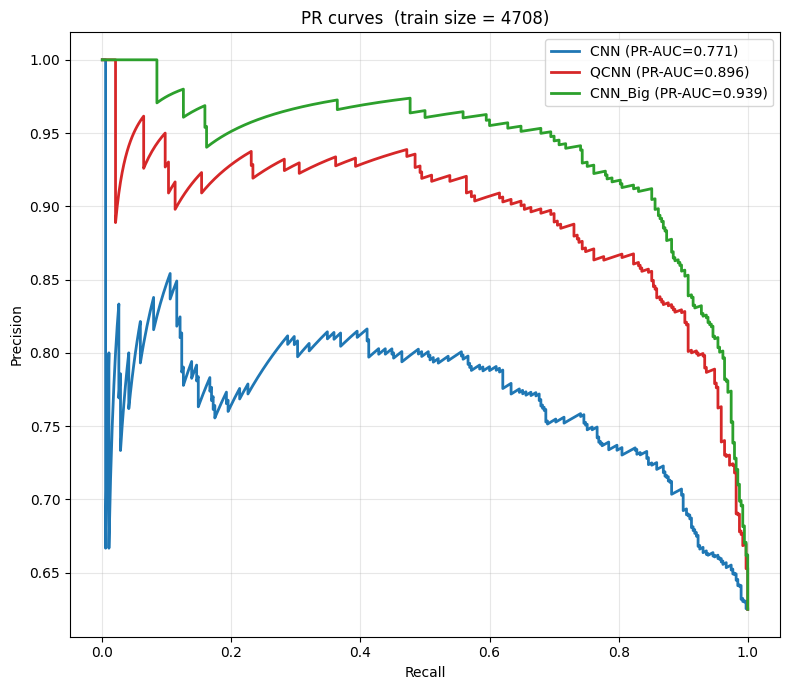

  Saved /content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/QCNN_VS_CNN(3)/sweep_plots/training_curves_sz4708.png


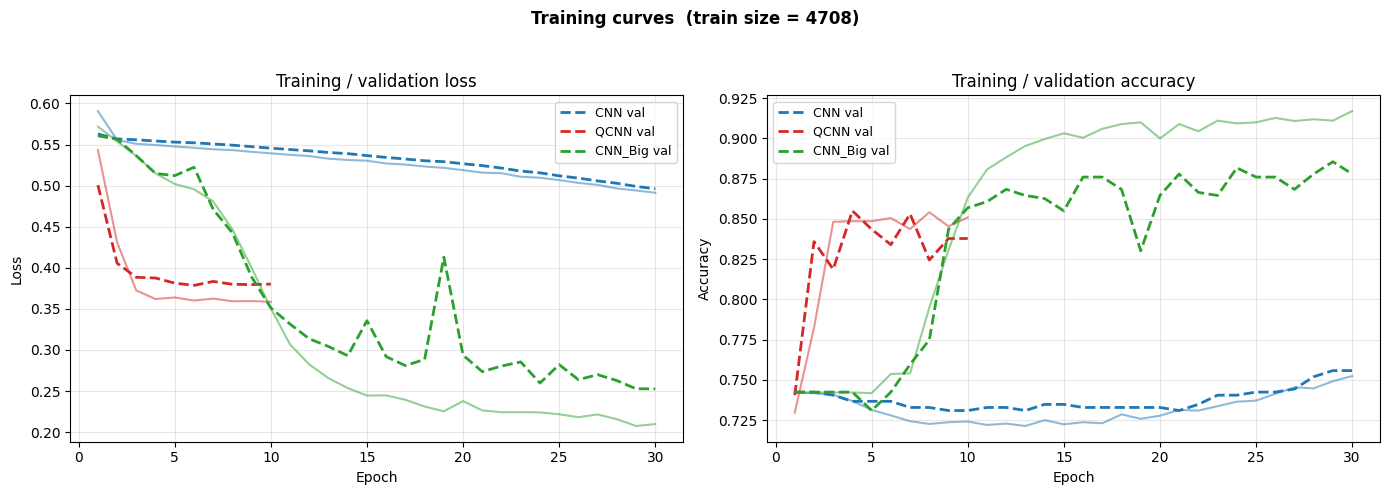

In [14]:
KPI_LIST = ['auc', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1', 'specificity']
KPI_LABELS = {
    'auc': 'ROC-AUC', 'pr_auc': 'PR-AUC', 'accuracy': 'Accuracy',
    'precision': 'Precision', 'recall': 'Recall (sensitivity)',
    'f1': 'F1 score', 'specificity': 'Specificity',
}


def _kv(r, k):
    return r[k] if k in ('auc', 'pr_auc') else r['tuned'][k]


def _save(fig, name):
    p = os.path.join(PLOT_DIR, name)
    fig.savefig(p, dpi=300, bbox_inches='tight')
    print(f"  Saved {p}")
    plt.show()
    plt.close(fig)


def plot_roc(R, sizes, names, size_idx=0):
    sz = sizes[size_idx]; fig, ax = plt.subplots(figsize=(8, 7))
    for n in names:
        r = R[n][sz][0]
        fpr, tpr, _ = roc_curve(r['test_labels'], r['test_probs'])
        ax.plot(fpr, tpr, lw=2, color=COLORS[n], label=f"{n} (AUC={r['auc']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set(xlabel='FPR', ylabel='TPR', title=f'ROC curves  (train size = {sz})')
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    _save(fig, f'roc_sz{sz}.png')


def plot_pr(R, sizes, names, size_idx=0):
    sz = sizes[size_idx]; fig, ax = plt.subplots(figsize=(8, 7))
    for n in names:
        r = R[n][sz][0]
        prec, rec, _ = precision_recall_curve(r['test_labels'], r['test_probs'])
        ax.plot(rec, prec, lw=2, color=COLORS[n], label=f"{n} (PR-AUC={r['pr_auc']:.3f})")
    ax.set(xlabel='Recall', ylabel='Precision', title=f'PR curves  (train size = {sz})')
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    _save(fig, f'pr_curve_sz{sz}.png')


def plot_training_curves(R, sizes, names, size_idx=0):
    sz = sizes[size_idx]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for n in names:
        r = R[n][sz][0]
        if 'train_losses' not in r:
            continue
        ep = range(1, len(r['train_losses']) + 1)
        axes[0].plot(ep, r['train_losses'], '-',  color=COLORS[n], lw=1.5, alpha=0.5)
        axes[0].plot(ep, r['val_losses'],   '--', color=COLORS[n], lw=2, label=f"{n} val")
        axes[1].plot(ep, r['train_accs'],   '-',  color=COLORS[n], lw=1.5, alpha=0.5)
        axes[1].plot(ep, r['val_accs'],     '--', color=COLORS[n], lw=2, label=f"{n} val")
    axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training / validation loss')
    axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Training / validation accuracy')
    for a in axes:
        a.legend(fontsize=9); a.grid(alpha=0.3)
    fig.suptitle(f'Training curves  (train size = {sz})', fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    _save(fig, f'training_curves_sz{sz}.png')


# %% ── MAIN ─────────────────────────────────────────────────────────────
def main():
    model_names = list(MODELS.keys())
    print(f"Models: {model_names}")
    print(f"Seeds : {SIZE_SEEDS}")
    print("All models see the SAME 20 pooled features; selection metric = val ROC-AUC.")
    print("Trainable parameters:")
    for name in model_names:
        print(f"  {name:8s}: {count_params(MODELS[name]())}")

    LABELS = dataset_labels(train_dataset)
    N_FULL = len(LABELS)
    print(f"Full train set: {N_FULL} samples, pneumonia frac {LABELS.mean():.3f}")

    sizes_sorted = sorted({(s if s is not None else N_FULL) for s in TRAIN_SIZES})
    all_results = {n: {sz: [] for sz in sizes_sorted} for n in model_names}

    for size in TRAIN_SIZES:
        size_key = size if size is not None else N_FULL
        print(f"\n{'='*60}\nTRAIN SIZE = {size_key}\n{'='*60}")
        for name in model_names:
            ctor = MODELS[name]
            for seed in SIZE_SEEDS:
                if is_done(name, size_key, seed):
                    r = load_result(name, size_key, seed)
                    all_results[name][size_key].append(r)
                    print(f"  {name:8s} seed={seed:<3}  LOADED  AUC={r['auc']:.4f}")
                    continue

                set_seed(seed)
                tl = subset_loader(train_dataset, LABELS, size, seed)
                print(f"  {name:8s} seed={seed:<3}  training on {len(tl.dataset)} samples …",
                      end=" ", flush=True)
                t0 = time.time()

                model, tr_l, vl_l, tr_a, vl_a, vl_auc = fit(ctor(), name, tl, val_loader, device)
                r = evaluate(model, name, val_loader, test_loader, device)
                r['train_losses'] = tr_l
                r['val_losses']   = vl_l
                r['train_accs']   = tr_a
                r['val_accs']     = vl_a
                r['val_aucs']     = vl_auc

                save_run(name, size_key, seed, model, r)
                all_results[name][size_key].append(r)
                print(f"AUC={r['auc']:.4f}  ({time.time()-t0:.1f}s)")

    # ---- aggregate save ----
    agg = os.path.join(CKPT_DIR, 'all_results.pkl')
    with open(agg, 'wb') as f:
        pickle.dump({'results': all_results, 'sizes': sizes_sorted,
                     'seeds': SIZE_SEEDS, 'models': model_names}, f)
    print(f"\nSaved aggregate -> {agg}")

    # ---- summary table (mean ± std over seeds) ----
    print(f"\n{'Model':<10}{'Size':>7}{'AUC(mean±std)':>18}{'PR-AUC':>9}"
          f"{'Acc':>8}{'F1':>8}{'Recall':>8}{'Spec':>8}")
    for name in model_names:
        for sz in sizes_sorted:
            runs = all_results[name][sz]
            if not runs:
                continue
            auc_m, auc_s = np.mean([r['auc'] for r in runs]), np.std([r['auc'] for r in runs])
            pr  = np.mean([r['pr_auc'] for r in runs])
            acc = np.mean([r['tuned']['accuracy'] for r in runs])
            f1  = np.mean([r['tuned']['f1'] for r in runs])
            rec = np.mean([r['tuned']['recall'] for r in runs])
            spc = np.mean([r['tuned']['specificity'] for r in runs])
            print(f"{name:<10}{sz:>7}{auc_m:>10.4f}±{auc_s:<6.4f}{pr:>9.4f}"
                  f"{acc:>8.4f}{f1:>8.4f}{rec:>8.4f}{spc:>8.4f}")

    # ---- plots ----
    print("\nGenerating plots …")

    plot_roc(all_results, sizes_sorted, model_names, size_idx=0)
    plot_pr(all_results, sizes_sorted, model_names, size_idx=0)
    plot_training_curves(all_results, sizes_sorted, model_names, size_idx=0)
    return all_results


# %% ── RUN ──────────────────────────────────────────────────────────────
all_results = main()